# Heart Disease Data Set: A Pandas and Seaborn-based Homework

DSE5002
HD Sheets, revised Feb 2025

We will be working with the heart.csv data set

https://www.kaggle.com/fedesoriano/heart-failure-prediction?select=heart.csv
    
using tools in pandas and seaborn,  and ideas from the two Jupyter notebooks we've seen this week



In [46]:
# setting up the libraries for this module

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
# make sure heart.csv is in your current working directory, or list the full path name in the variable infile

# the file path in the variable infile below shows the location of this file on my drive, you will 
# need to alter this to match where it is on your system- ideally place it in your working directory
#
# see this week's pair programming on how to locate your current working directory

infile="heart-1.csv"

bp_df=pd.read_csv(infile)
bp_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Homework Questions: Basic Data Exploration

Find or create the following using Python code

a.) -Find the dimensions,   memory used, and other basic information about this data set.   Check for missing data (NAs)


b.) -Run the data summary


c.) Change the appropriate variables to type Categorical

d.) -Create a pivot table (using the Pandas groupby operation) showing mean Resting BP by Sex, Resting ECG and HeartDisease-What does this tell you? What else can you figure out using a Pivot table, show me two other helpful pivot tables based on different variables, different groupings or different aggregation functions (count, mean, max etc)

e.) -Show a histogram and the ECDF  (empirical cumulative distribution function) for several continuous variables in the data set,   in broad 
    terms, what do the distributions look like,  normal? exponential, poison-like?, uniform?   Does this match your expectations?

    https://seaborn.pydata.org/generated/seaborn.ecdfplot.html
    https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.ecdf.html
    

f.) -Show An SNS Pairplot,   the most informative version you can find,   set the hue based on Heart Disease,  try using at least one
other variable as the Hue.  Discuss what you think you are seeing in this plot


Create all these results in this Notebook and turn it in

In [52]:
print (dir(bp_df))

print (bp_df.shape)

print (bp_df.memory_usage())

print (bp_df.dtypes)

explicit_nulls = bp_df.isna().sum()

zero_counts = (bp_df == 0).sum()

missing_summary = pd.DataFrame({
    'Explicit NAs (isna)': explicit_nulls,
    'Zero Counts': zero_counts,
})
print(missing_summary)

['Age', 'ChestPainType', 'Cholesterol', 'ExerciseAngina', 'FastingBS', 'HeartDisease', 'MaxHR', 'Oldpeak', 'RestingBP', 'RestingECG', 'ST_Slope', 'Sex', 'T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__array_wrap__', '__bool__', '__class__', '__contains__', '__copy__', '__dataframe__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__p

In [26]:
#b)
print (bp_df.describe())

              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  


In [27]:
#c.) Change the appropriate variables to type Categorical
bp_df['Sex'] = pd.Categorical(bp_df.Sex)
bp_df['RestingECG'] = pd.Categorical(bp_df.RestingECG)
bp_df['ChestPainType'] = pd.Categorical(bp_df.ChestPainType)
bp_df['ExerciseAngina'] = pd.Categorical(bp_df.ExerciseAngina)
bp_df['HeartDisease'] = bp_df['HeartDisease'].astype(bool)
bp_df['ST_Slope'] = pd.Categorical(bp_df.ST_Slope)
bp_df.dtypes


Age                  int64
Sex               category
ChestPainType     category
RestingBP            int64
Cholesterol          int64
FastingBS            int64
RestingECG        category
MaxHR                int64
ExerciseAngina    category
Oldpeak            float64
ST_Slope          category
HeartDisease          bool
dtype: object

d.) -Create a pivot table (using the Pandas groupby operation) showing mean Resting BP by Sex, Resting ECG and HeartDisease-What does this tell you? What else can you figure out using a Pivot table, show me two other helpful pivot tables based on different variables, different groupings or different aggregation functions (count, mean, max etc)

In [28]:
pivot_resting_bp = (
    bp_df.groupby(["Sex", "RestingECG", "HeartDisease"])["RestingBP"]
    .mean()
    .unstack(level="HeartDisease")
)

# Rename columns for clarity
pivot_resting_bp.columns = [
    "No Heart Disease (0)",
    "Heart Disease (1)",
]

print("--- Mean Resting BP (mmHg) by Sex, Resting ECG, and Heart Disease ---")
print(pivot_resting_bp.round(2))



--- Mean Resting BP (mmHg) by Sex, Resting ECG, and Heart Disease ---
                No Heart Disease (0)  Heart Disease (1)
Sex RestingECG                                         
F   LVH                       128.70             148.93
    Normal                    129.12             139.31
    ST                        127.52             139.29
M   LVH                       131.84             135.47
    Normal                    129.92             130.68
    ST                        134.28             137.73


In [29]:
pivot_resting_bp = (
    bp_df.groupby(["Sex", "RestingECG", "HeartDisease"])["RestingBP"]
    .std()
    .unstack(level="HeartDisease")
)

# Rename columns for clarity
pivot_resting_bp.columns = [
    "No Heart Disease (0)",
    "Heart Disease (1)",
]

print(pivot_resting_bp)

                No Heart Disease (0)  Heart Disease (1)
Sex RestingECG                                         
F   LVH                    14.149834          19.112880
    Normal                 17.093207          25.271530
    ST                     18.848393          22.020553
M   LVH                    16.449857          19.409101
    Normal                 15.882851          19.309663
    ST                     18.497384          18.114776



e.) -Show a histogram and the ECDF  (empirical cumulative distribution function) for several continuous variables in the data set,   in broad 
    terms, what do the distributions look like,  normal? exponential, poison-like?, uniform?   Does this match your expectations?

    https://seaborn.pydata.org/generated/seaborn.ecdfplot.html
    https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.ecdf.html

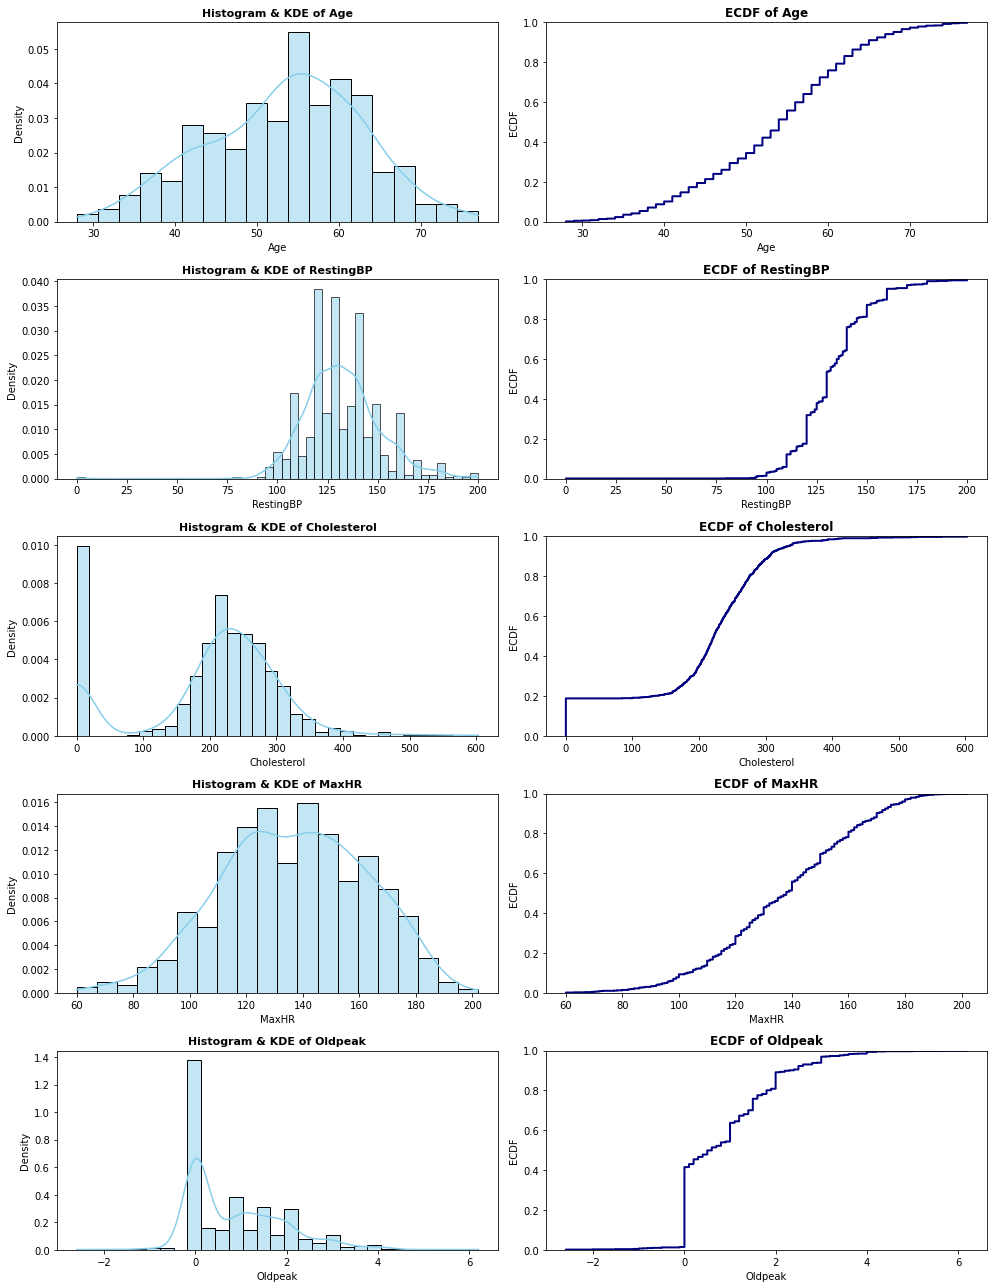

In [53]:

continuous_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

fig, axes = plt.subplots(len(continuous_cols), 2, figsize=(14, 18))

for i, col in enumerate(continuous_cols):
    sns.histplot(
        bp_df[col], kde=True, ax=axes[i, 0], color="skyblue", stat="density"
    )
    axes[i, 0].set_title(f"Histogram & KDE of {col}", fontsize=11, fontweight="bold")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Density")

    sns.ecdfplot(bp_df[col], ax=axes[i, 1], color="navy", linewidth=2)
    axes[i, 1].set_title(f"ECDF of {col}", fontsize=12, fontweight="bold")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("ECDF")

plt.tight_layout()
plt.show()

The sharp jump at cholesterol point zero shows probably a missing data piece. Histogram and Kde of age is normal and so is max hr and cholesterol when you ignore the outlier. Resting Bp is multimodal since there are jumps in the normal distribution. Old peak is exponential because it starts high and plummets down ward. 


f.) -Show An SNS Pairplot,   the most informative version you can find,   set the hue based on Heart Disease,  try using at least one
other variable as the Hue.  Discuss what you think you are seeing in this plot

### Maximum Heart Rate (MaxHR) vs. Age: There is a clear negative correlation between Age and MaxHR. Patients with Heart Disease (HeartDisease = 1) consistently cluster toward lower maximum heart rates compared to healthy patients across similar age groups.

### ST Depression (Oldpeak): The KDE distributions along the diagonal show that patients without heart disease (0) strongly peak at an Oldpeak value near 0. High values of Oldpeak heavily correlate with the presence of heart disease (1).

### Age Distribution: The density curve demonstrates that patients diagnosed with heart disease lean toward an older demographic (peak density around 55–65 years) compared to non-disease patients (peak around 45–55 years).

### Cholesterol Anomalies: A notable cluster of 0 values exists for Cholesterol (representing missing/unrecorded entries in the clinical dataset), which shows up as a secondary spike in the KDE plot.

### Sex Differences: When comparing across Sex, male observations (M) vastly outnumber females (F) in this sample dataset, but both sexes follow a similar age-to-maximum-heart-rate trajectory.

Create all these results in this Notebook and turn it in

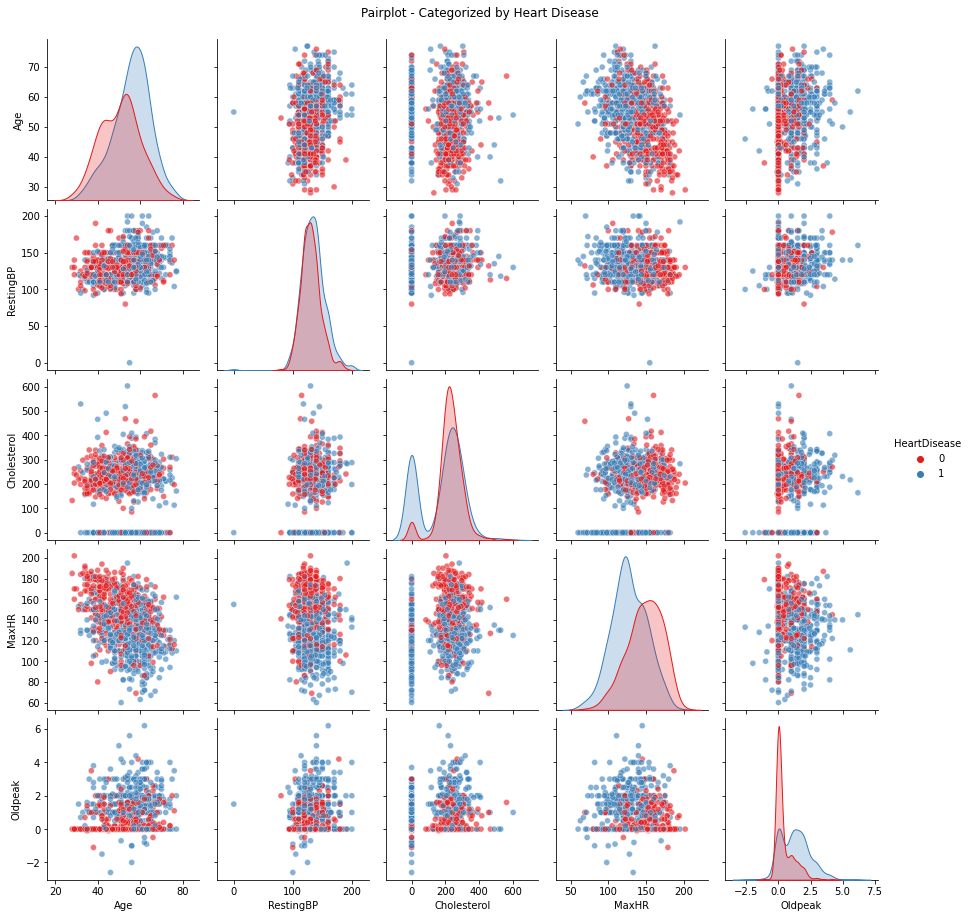

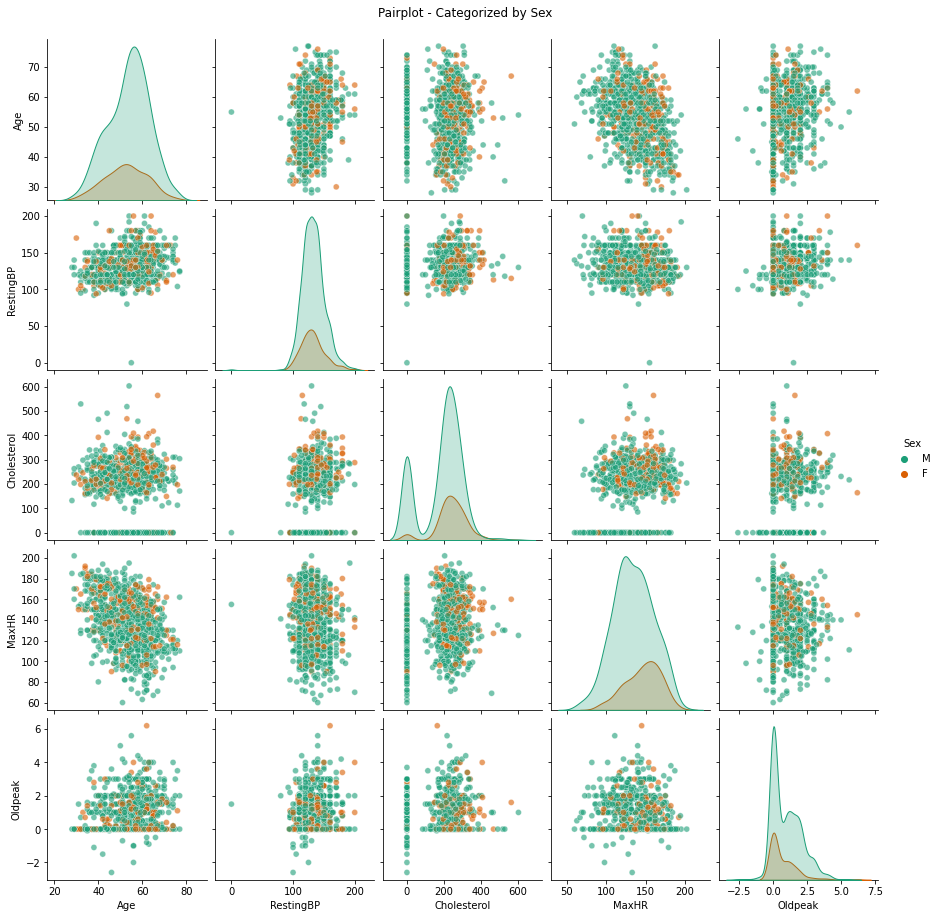

In [32]:


# Load dataset
df = pd.read_csv('heart-1.csv')

# Continuous numerical features selected for maximum clarity
features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# 1. Primary Pairplot: Hue based on HeartDisease
sns.pairplot(
    df, 
    vars=features, 
    hue='HeartDisease', 
    palette='Set1', 
    diag_kind='kde', 
    plot_kws={'alpha': 0.6}
)
plt.suptitle("Pairplot - Categorized by Heart Disease", y=1.02)
plt.show()

# 2. Secondary Pairplot: Hue based on Sex (Alternative Variable)
sns.pairplot(
    df, 
    vars=features, 
    hue='Sex', 
    palette='Dark2', 
    diag_kind='kde', 
    plot_kws={'alpha': 0.6}
)
plt.suptitle("Pairplot - Categorized by Sex", y=1.02)
plt.show()

g.) Create several useful or informative boxplots of continuous variables by category, using Seaborn or PlotNine.   Find an interesting result or contrast 
among the variables,   discuss what you think it means or implies

# Maximum Heart Rate (MaxHR) Suppression: Across every chest pain category (ASY, ATA, NAP, TA), patients with Heart Disease consistently present lower median maximum heart rates (e.g., median MaxHR of 125 bpm for ASY patients with disease vs. 140 bpm for those without).

# Clinical Implication: Indicates chronotropic incompetence—the inability of the heart to increase its rate commensurate with increased activity—which is a well-documented marker of coronary artery disease.


# ST Depression (Oldpeak) vs. ST_Slope Contrast: Patients with an Upward ST slope without heart disease show a near-zero median Oldpeak. Conversely, patients with Flat or Downwards ST slopes alongside a Heart Disease diagnosis exhibit elevated ST depression (medians of 1.2 and 2.0, with upper extremes reaching 6.2).

# Clinical Implication: An abnormal, flat, or decreasing ST segment slope during peak exercise combined with high ST depression is a strong diagnostic signature for severe myocardial ischemia.

# Data Anomaly in Cholesterol: The Cholesterol boxplots reveal a heavy concentration of zero values 0 (mg/dL) primarily within the HeartDisease = 1 group, pulling the 25th percentile down to 0.

# Clinical Implication: Highlights unrecorded/missing clinical measurement data that was encoded as zero, which requires data imputation or filtering prior to downstream predictive modeling.


# Age vs. Sex Interactions: Age distributions for heart disease cases are nearly identical between males and females (median age ~57–58 years for both sexes with heart disease, compared to ~51 years for healthy controls).

# Clinical Implication: While overall incidence rate differs by sex, the age-onset threshold for severe heart disease progression remains roughly parallel for men and women.

h.) Create violin plots of these same results

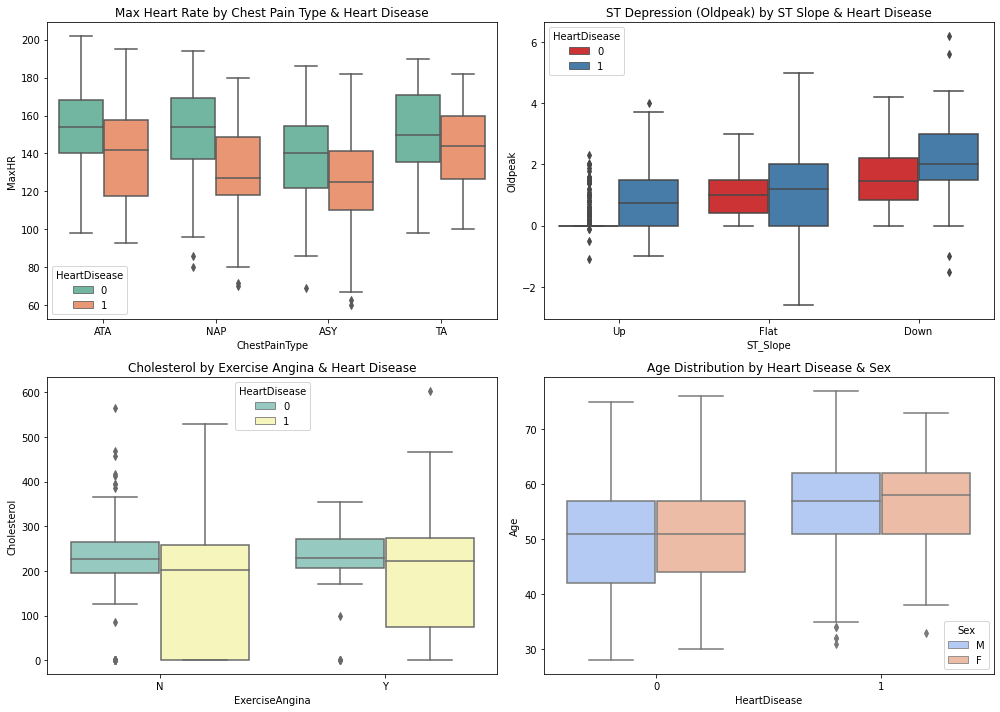

In [34]:

# Configure multi-panel boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Max Heart Rate by Chest Pain Type and Heart Disease
sns.boxplot(data=df, x='ChestPainType', y='MaxHR', hue='HeartDisease', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Max Heart Rate by Chest Pain Type & Heart Disease')

# 2. ST Depression (Oldpeak) by ST Slope and Heart Disease
sns.boxplot(data=df, x='ST_Slope', y='Oldpeak', hue='HeartDisease', palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title('ST Depression (Oldpeak) by ST Slope & Heart Disease')

# 3. Cholesterol by Exercise Induced Angina and Heart Disease
sns.boxplot(data=df, x='ExerciseAngina', y='Cholesterol', hue='HeartDisease', palette='Set3', ax=axes[1, 0])
axes[1, 0].set_title('Cholesterol by Exercise Angina & Heart Disease')

# 4. Age Distribution by Heart Disease and Sex
sns.boxplot(data=df, x='HeartDisease', y='Age', hue='Sex', palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Age Distribution by Heart Disease & Sex')

plt.tight_layout()
plt.show()

In [ ]:
h.) Create violin plots of these same results

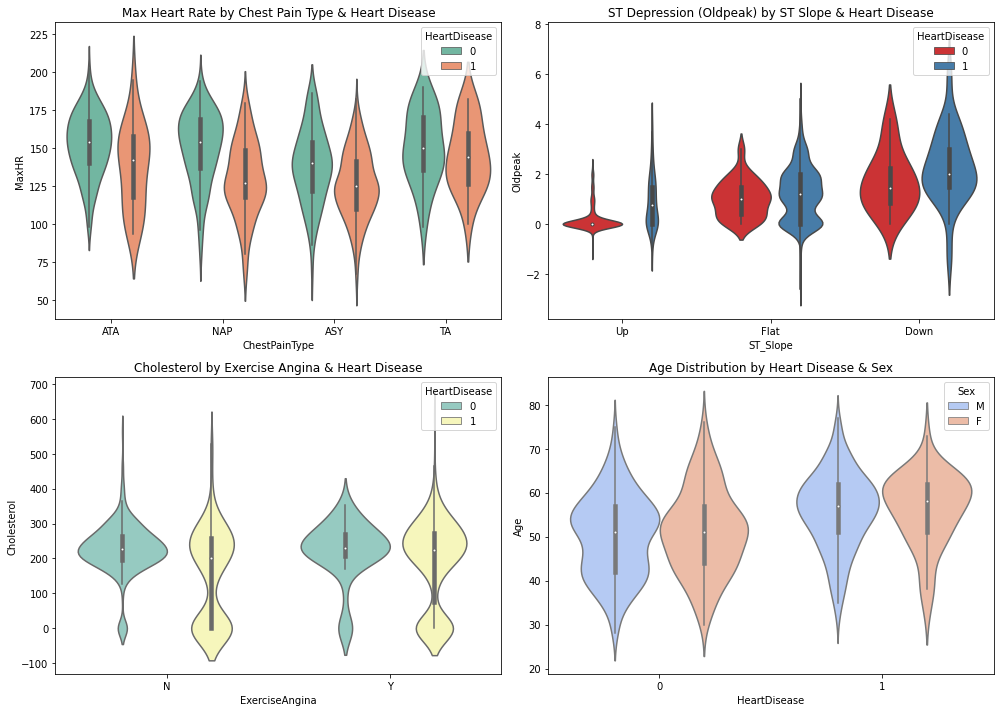

In [35]:
# Configure multi-panel boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Max Heart Rate by Chest Pain Type and Heart Disease
sns.violinplot(data=df, x='ChestPainType', y='MaxHR', hue='HeartDisease', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Max Heart Rate by Chest Pain Type & Heart Disease')

# 2. ST Depression (Oldpeak) by ST Slope and Heart Disease
sns.violinplot(data=df, x='ST_Slope', y='Oldpeak', hue='HeartDisease', palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title('ST Depression (Oldpeak) by ST Slope & Heart Disease')

# 3. Cholesterol by Exercise Induced Angina and Heart Disease
sns.violinplot(data=df, x='ExerciseAngina', y='Cholesterol', hue='HeartDisease', palette='Set3', ax=axes[1, 0])
axes[1, 0].set_title('Cholesterol by Exercise Angina & Heart Disease')

# 4. Age Distribution by Heart Disease and Sex
sns.violinplot(data=df, x='HeartDisease', y='Age', hue='Sex', palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Age Distribution by Heart Disease & Sex')

plt.tight_layout()
plt.show()

### Creating Tables

1.) Find the mean, median and standard deviation of the Max heartrate variable in this data set

Turn this into a pivot table,   grouping by one or more predictors.   Try this for several different predictors to see if you can 
find any "structure" in the data, meaning indications of correlations of variables

What does this table tell you?   If you tried several tables, explain the most interesting of them

In [54]:


# --- Overall Statistics for MaxHR ---
mean_hr = bp_df['MaxHR'].mean()
median_hr = bp_df['MaxHR'].median()
std_hr = bp_df['MaxHR'].std()

print(f"MaxHR Statistics:")
print(f"Mean:   {mean_hr:.2f}")
print(f"Median: {median_hr:.2f}")
print(f"Std:    {std_hr:.2f}\n")

# --- Primary Pivot Table: MaxHR grouped by ST_Slope & HeartDisease ---
pivot_st = pd.pivot_table(
    bp_df,
    values='MaxHR',
    index='ST_Slope',
    columns='HeartDisease',
    aggfunc=['mean', 'median', 'std']
)

print("--- Pivot Table: ST_Slope vs HeartDisease ---")
print(pivot_st)

# --- Additional Pivot Table Explorations ---

# 1. MaxHR by Chest Pain Type and Heart Disease
pivot_chest_pain = pd.pivot_table(
    bp_df,
    values='MaxHR',
    index='ChestPainType',
    columns='HeartDisease',
    aggfunc=['mean', 'median', 'std']
)

# 2. MaxHR by Exercise Induced Angina and Heart Disease
pivot_angina = pd.pivot_table(
    bp_df,
    values='MaxHR',
    index='ExerciseAngina',
    columns='HeartDisease',
    aggfunc=['mean', 'median', 'std']
)

print("\n--- Pivot Table: ChestPainType vs HeartDisease ---")
print(pivot_chest_pain)

print("\n--- Pivot Table: ExerciseAngina vs HeartDisease ---")
print(pivot_angina)

MaxHR Statistics:
Mean:   136.81
Median: 138.00
Std:    25.46

--- Pivot Table: ST_Slope vs HeartDisease ---
                    mean             median               std           
HeartDisease           0           1      0      1          0          1
ST_Slope                                                                
Down          141.785714  126.551020  147.5  127.0  32.859090  20.152607
Flat          143.455696  124.929134  146.0  124.0  22.098728  22.495677
Up            149.602524  141.666667  150.0  144.0  22.968740  24.785661

--- Pivot Table: ChestPainType vs HeartDisease ---
                     mean             median             std           
HeartDisease            0           1      0    1          0          1
ChestPainType                                                          
ASY            138.548077  125.806122    140  125  24.303054  22.548343
ATA            152.255034  137.500000    154  142  20.748219  27.327323
NAP            150.641221  129.763889    

# Strong Interaction Between Predictors: The most informative pivot table combines ST_Slope and HeartDisease. Across every slope category, patients diagnosed with heart disease (1) exhibit significantly lower mean and median peak heart rates compared to their healthy counterparts (0).

# Upward Slope Buffer: Patients with an Upward ST slope maintain the highest overall heart rates regardless of disease status (mean 149.60 bpm  for healthy vs. 141.67 bpm for diseased, confirming that an upward slope correlates with better cardiac capacity.

# Flat Slope Impact: The gap is most severe among patients with a Flat ST slope: healthy patients reach a mean MaxHR of 143.46 bpm}median 146.00, whereas patients with heart disease drop to a mean of 124.93 bpm (median 124.00)—an average drop of nearly 19.5 bpm.

Chest Pain Type vs. Heart Disease

# Asymptomatic (ASY) Drop: Patients presenting with asymptomatic chest pain (ASY) have lower maximum heart rates overall, but those with heart disease average only 125.81 bpm} (median 125.00) compared to 138.55 bpm} (median 140.00) for those without.

# Non-Anginal Pain (NAP) & Atypical Angina (ATA): In both NAP and ATA groups, healthy patients achieve strong maximum heart rates (means of 150.64  bpm and 152.26 bpm respectively). When heart disease is present, maximum heart rates drop substantially by  21 bpm in NAP to 129.76 bpm and  15 bpm in ATA to 137.50 bpm.

# Typical Angina (TA) Resilience: Patients presenting with Typical Angina show the smallest separation between healthy 150.50 bpm and diseased 144.50 bpm cohorts, suggesting typical angina symptoms occur closer to peak exertion regardless of underlying condition severity.

Table 3: ExerciseAngina vs. HeartDiseaseCompound Suppression Effect: 
# Patients who experience exercise-induced angina (Y) and have heart disease (1) suffer from the lowest average maximum heart rate in the entire analysis (mean 123.16 bpm, median 122.0 bpm).

# No-Angina Baseline: Healthy patients without exercise-induced angina (N) achieve the highest average maximum heart rate (mean 149.72 bpm, median 151.0 bpm).

# Diagnostic Dual-Signal: Exercise-induced angina acts as a compounding barrier: even healthy individuals who experience exercise angina drop to a mean MaxHR of 138.02 bp, showing that physical onset of angina directly restricts peak heart rate capacity.
